We will train our Support Vector Machine model with the dataset of diabetes.

# Our first task is to Load the dataset from GitHub.

In [1]:
import pandas as pd

GITHUB_RAW_URL="https://raw.githubusercontent.com/mdraihan27/svm-and-knn/refs/heads/main/diabetes.csv"

df = pd.read_csv(GITHUB_RAW_URL)


# Now we will explore our dataset.

Now, let's see some details about our dataset.

In [2]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['Outcome'].value_counts().rename({0: 'Non-Diabetic', 1: 'Diabetic'}))
print(f"\nFirst 5 rows:")
print(df.head())
print("\nDataset description\n")
print(df.describe())

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class distribution:
Outcome
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset description

       Pregnancies  

Lets visualize the relations between different columns with outcome in out dataset.

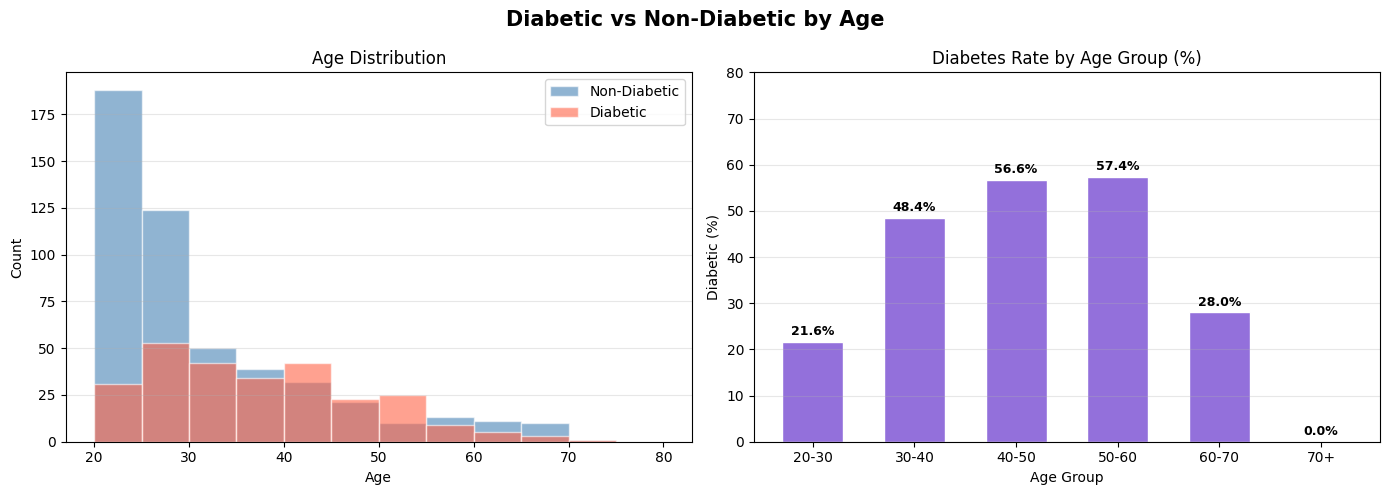

In [3]:
import matplotlib.pyplot as plt
import numpy as np

diabetic = df[df['Outcome'] == 1]['Age']
non_diabetic = df[df['Outcome'] == 0]['Age']

age_bins = range(20, 85, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diabetic vs Non-Diabetic by Age', fontsize=15, fontweight='bold')

axes[0].hist(non_diabetic, bins=age_bins, alpha=0.6, color='steelblue', label='Non-Diabetic', edgecolor='white')
axes[0].hist(diabetic,     bins=age_bins, alpha=0.6, color='tomato',    label='Diabetic',     edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,90],
                         labels=['20-30','30-40','40-50','50-60','60-70','70+'])
rate = df.groupby('AgeGroup', observed=True)['Outcome'].mean() * 100

bars = axes[1].bar(rate.index, rate.values, color='mediumpurple', edgecolor='white', width=0.6)
axes[1].set_title('Diabetes Rate by Age Group (%)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Diabetic (%)')
axes[1].set_ylim(0, 80)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

df.drop(columns=['AgeGroup'], inplace=True)

Though we get very clear view over age by diabetes relation, but from the histogram we can assume that our dataset contains much more member of 20-30 age than other age groups.

Lets make this sure by visualizing number of people in different age groups.

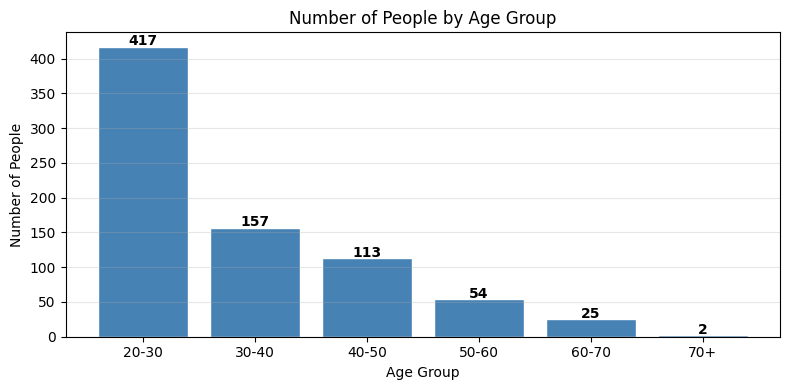

In [4]:
import pandas as pd

df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,90],
                         labels=['20-30','30-40','40-50','50-60','60-70','70+'])

counts = df['AgeGroup'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='white')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

plt.title('Number of People by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df.drop(columns=['AgeGroup'], inplace=True)

Let's see the relation between BMI and diabetes

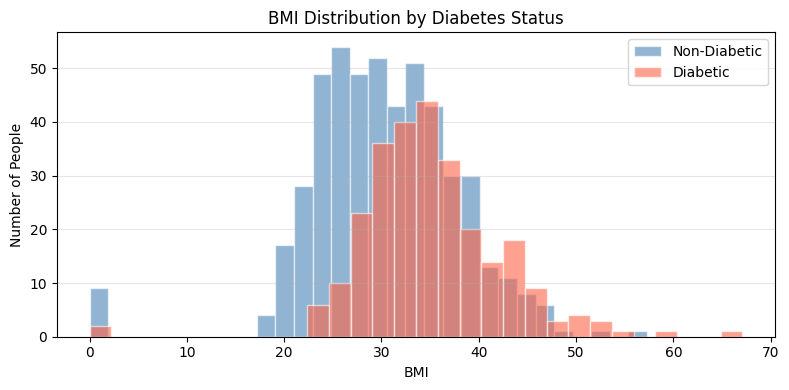

In [5]:
diabetic = df[df['Outcome'] == 1]['BMI']
non_diabetic = df[df['Outcome'] == 0]['BMI']

plt.figure(figsize=(8, 4))
plt.hist(non_diabetic, bins=30, alpha=0.6, color='steelblue', label='Non-Diabetic', edgecolor='white')
plt.hist(diabetic, bins=30, alpha=0.6, color='tomato', label='Diabetic', edgecolor='white')

plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('BMI')
plt.ylabel('Number of People')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Let's view how all of the features relate to the outcome

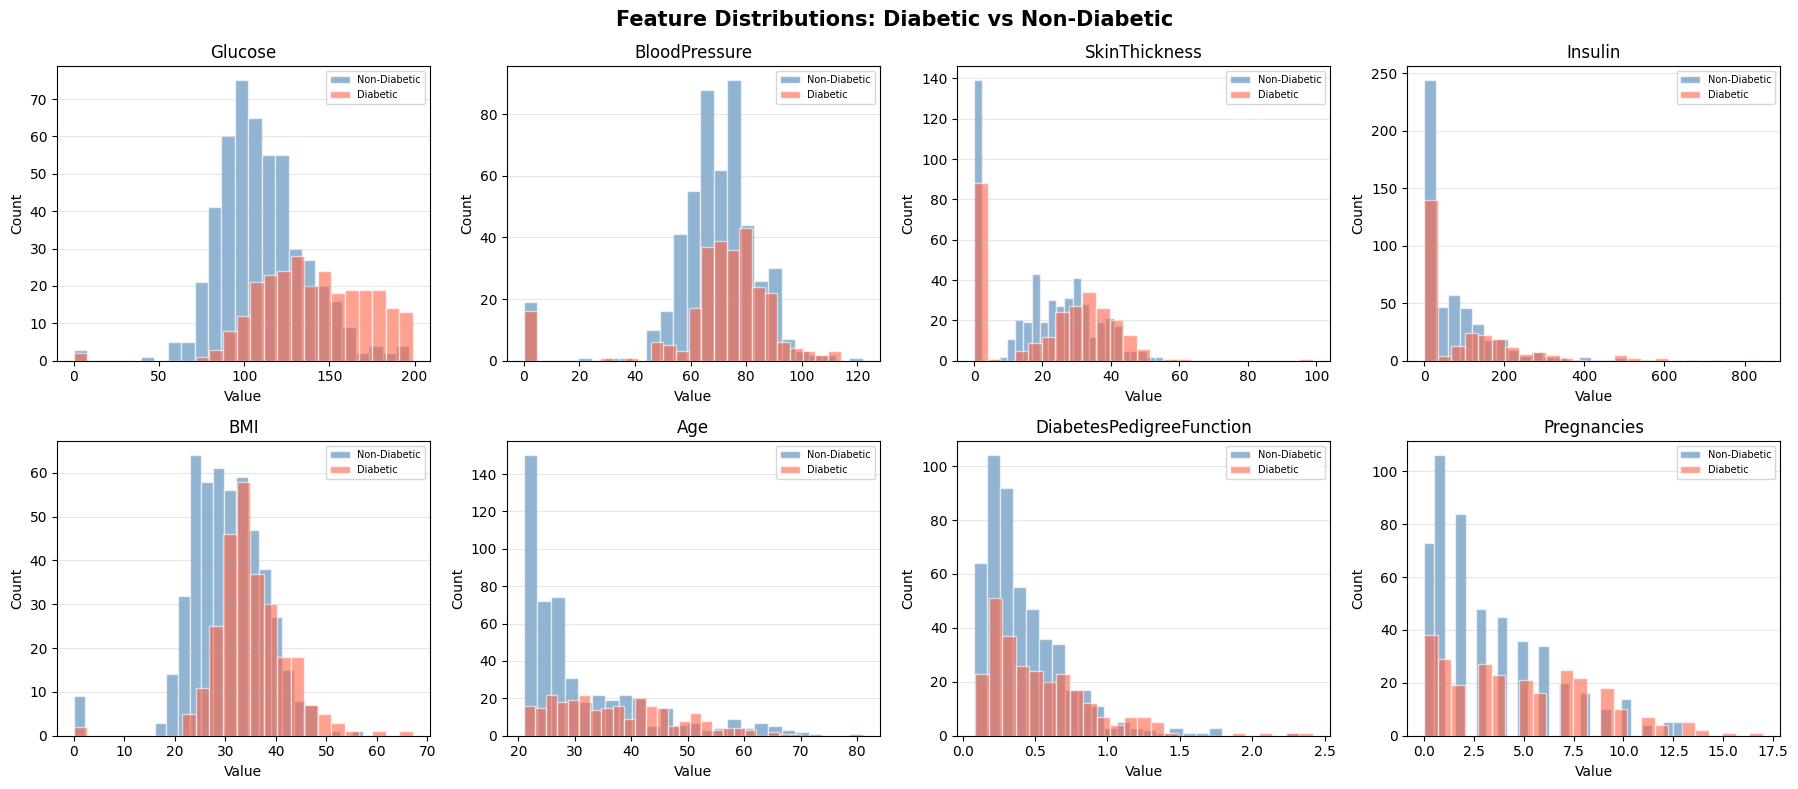

In [6]:
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Pregnancies']

diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions: Diabetic vs Non-Diabetic', fontsize=15, fontweight='bold')

for ax, feature in zip(axes.flatten(), features):
    ax.hist(non_diabetic[feature], bins=25, alpha=0.6, color='steelblue', label='Non-Diabetic', edgecolor='white')
    ax.hist(diabetic[feature],     bins=25, alpha=0.6, color='tomato',    label='Diabetic',     edgecolor='white')
    ax.set_title(feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

So, the conclusion I have come to is that,
1. Glucose is highly responsible for diabetes.
2. Poeple with diabetes tend to have more blood pressure, but not so much.
3. Skin Thickness is also somewhat related to diabetes.
4. Insulin is also somewhat related.
5. BMI is highly responsible, more BMI means more chance of getting diabetes.
6. Young poeple tend to get diabetes less.
7. People with less Diabetes Pedigree Function has less chance of getting diabetes.
8. Pregnency seems to have somewhat effect.

If we generate a correlation heatmap, then it will be more clear.

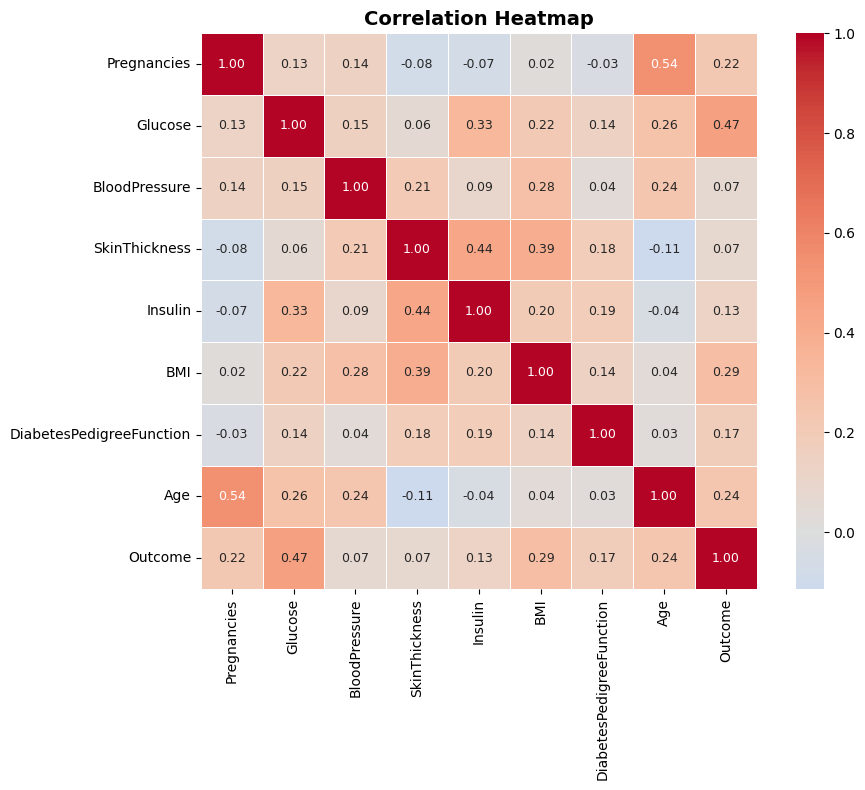

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

So, the blood pressure and skin thikness have the least relation with diabetes.

Let's view the relation between different features.

Scatter plot of glucose by BMI.

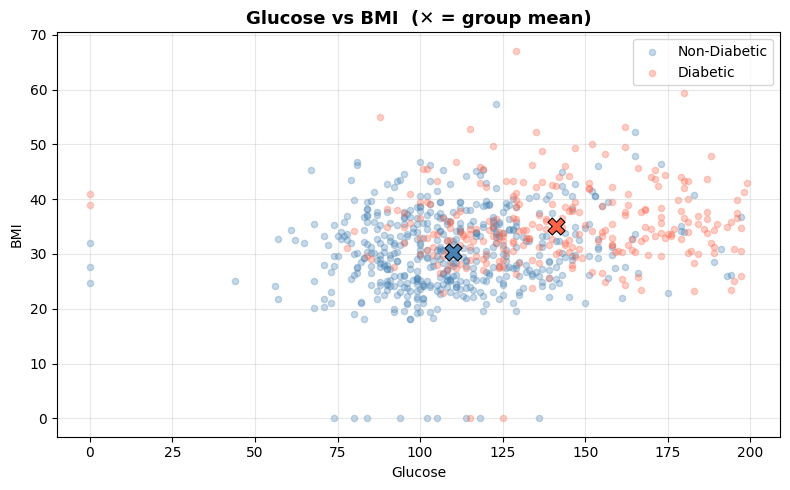

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, color, name in [(0,'steelblue','Non-Diabetic'), (1,'tomato','Diabetic')]:
    subset = df[df['Outcome'] == label]
    ax.scatter(subset['Glucose'], subset['BMI'], alpha=0.3, c=color, s=20, label=name)

    ax.scatter(subset['Glucose'].mean(), subset['BMI'].mean(),
               c=color, s=150, marker='X', edgecolors='black', linewidths=0.8, zorder=5)

ax.set_xlabel('Glucose')
ax.set_ylabel('BMI')
ax.set_title('Glucose vs BMI  (✕ = group mean)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Glucose by BMI scatter plot

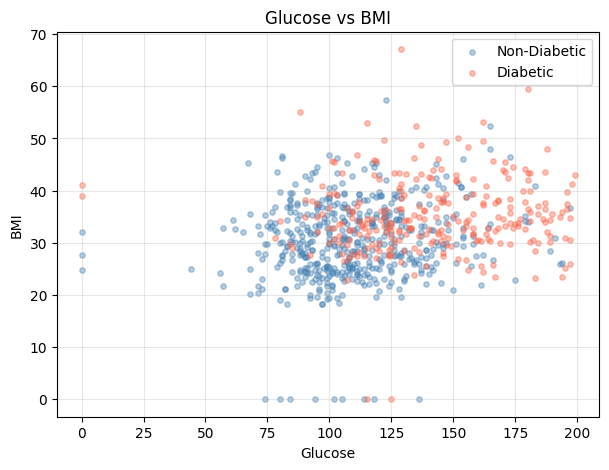

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(df[df['Outcome']==0]['Glucose'], df[df['Outcome']==0]['BMI'], alpha=0.4, color='steelblue', s=15, label='Non-Diabetic')
plt.scatter(df[df['Outcome']==1]['Glucose'], df[df['Outcome']==1]['BMI'], alpha=0.4, color='tomato', s=15, label='Diabetic')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose vs BMI')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Glucose vs blood pressure scatter plot

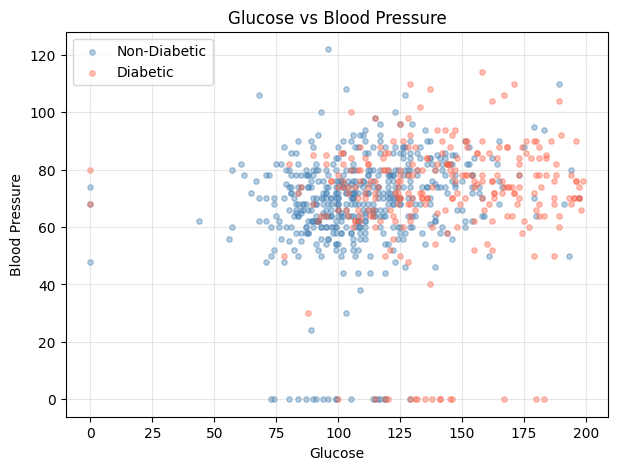

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(df[df['Outcome']==0]['Glucose'], df[df['Outcome']==0]['BloodPressure'], alpha=0.4, color='steelblue', s=15, label='Non-Diabetic')
plt.scatter(df[df['Outcome']==1]['Glucose'], df[df['Outcome']==1]['BloodPressure'], alpha=0.4, color='tomato', s=15, label='Diabetic')
plt.xlabel('Glucose')
plt.ylabel('Blood Pressure')
plt.title('Glucose vs Blood Pressure')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Age vs blood pressure scatter plot.

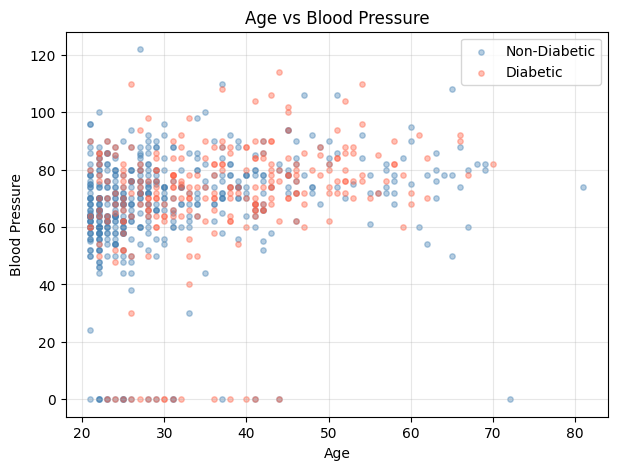

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(df[df['Outcome']==0]['Age'], df[df['Outcome']==0]['BloodPressure'], alpha=0.4, color='steelblue', s=15, label='Non-Diabetic')
plt.scatter(df[df['Outcome']==1]['Age'], df[df['Outcome']==1]['BloodPressure'], alpha=0.4, color='tomato', s=15, label='Diabetic')
plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.title('Age vs Blood Pressure')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Lets view analysis of amount of missing values in columns.

              FULL NULL & ZERO VALUE ANALYSIS — ALL COLUMNS
                          Null Count  Null %  Zero Count  Zero %    Dtype    Min     Max    Mean  Median
Pregnancies                        0     0.0         111   14.45    int64   0.00   17.00    3.85    3.00
Glucose                            0     0.0           5    0.65    int64   0.00  199.00  120.89  117.00
BloodPressure                      0     0.0          35    4.56    int64   0.00  122.00   69.11   72.00
SkinThickness                      0     0.0         227   29.56    int64   0.00   99.00   20.54   23.00
Insulin                            0     0.0         374   48.70    int64   0.00  846.00   79.80   30.50
BMI                                0     0.0          11    1.43  float64   0.00   67.10   31.99   32.00
DiabetesPedigreeFunction           0     0.0           0    0.00  float64   0.08    2.42    0.47    0.37
Age                                0     0.0           0    0.00    int64  21.00   81.00   33.24   2

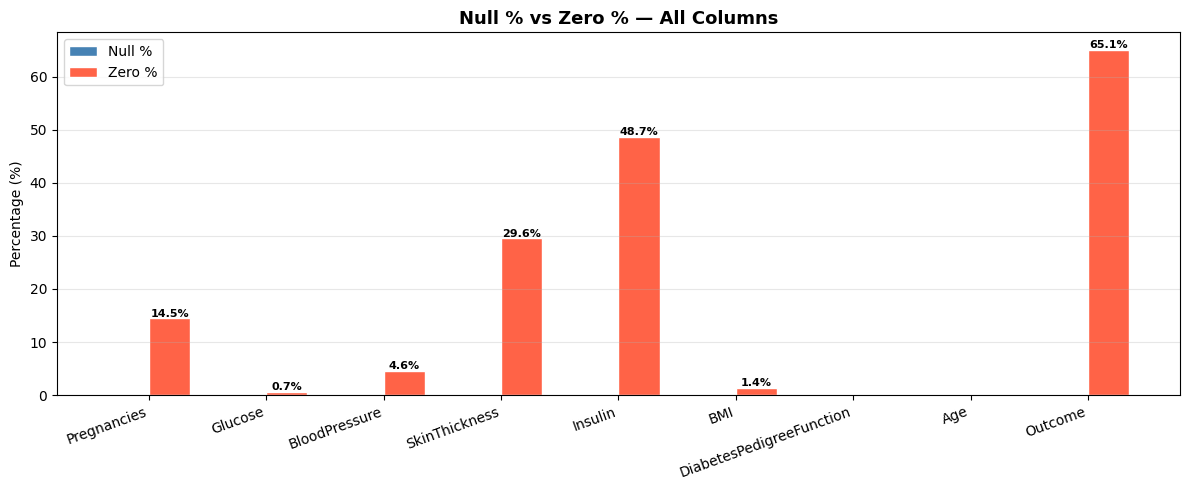

In [12]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

zero_counts = (df == 0).sum()
zero_pct = ((df == 0).mean() * 100).round(2)

summary = pd.DataFrame({
    'Null Count':  null_counts,
    'Null %':      null_pct,
    'Zero Count':  zero_counts,
    'Zero %':      zero_pct,
    'Dtype':       df.dtypes,
    'Min':         df.min().round(2),
    'Max':         df.max().round(2),
    'Mean':        df.mean().round(2),
    'Median':      df.median().round(2),
})

print("=" * 75)
print("              FULL NULL & ZERO VALUE ANALYSIS — ALL COLUMNS")
print("=" * 75)
print(summary.to_string())
print("=" * 75)
print(f"Total rows: {len(df)}  |  Total columns: {len(df.columns)}")

cols = df.columns.tolist()
null_pct = (df.isnull().mean() * 100).values
zero_pct = ((df == 0).mean() * 100).values

x = np.arange(len(cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, null_pct, width, color='steelblue', label='Null %', edgecolor='white')
bars2 = ax.bar(x + width/2, zero_pct, width, color='tomato',    label='Zero %', edgecolor='white')

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=20, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Null % vs Zero % — All Columns', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This means there is no null value in anywhere, but there are zero values.

# Now, we will perform data preprocessing.

As, Glucose, Bloodpressure, SkinThickness, insulin, BMI cannot be zero, so we need to fill the zeros.

In [13]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    median = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median)

print(df[zero_cols].describe().round(2))

       Glucose  BloodPressure  SkinThickness  Insulin     BMI
count   768.00         768.00         768.00   768.00  768.00
mean    121.66          72.39          29.11   140.67   32.46
std      30.44          12.10           8.79    86.38    6.88
min      44.00          24.00           7.00    14.00   18.20
25%      99.75          64.00          25.00   121.50   27.50
50%     117.00          72.00          29.00   125.00   32.30
75%     140.25          80.00          32.00   127.25   36.60
max     199.00         122.00          99.00   846.00   67.10


Lets encode categorical feature

In [14]:
import pandas as pd

df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 40, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Extremely_Obese'])
df['BMI_Category'] = df['BMI_Category'].astype(str)
df = pd.get_dummies(df, columns=['BMI_Category'], drop_first=True)

print("Categorical feature encoded")
print(f"New shape: {df.shape}")
print(f"New columns added: {[c for c in df.columns if 'BMI_Category' in c]}")
print(df.head())

Categorical feature encoded
New shape: (768, 13)
New columns added: ['BMI_Category_Normal', 'BMI_Category_Obese', 'BMI_Category_Overweight', 'BMI_Category_Underweight']
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  BMI_Category_Normal  \
0                     0.627   50        1                False   
1                     0.351   31        0                False   
2                     0.672   32        1                 True   
3                     0.167   21        0                False   
4                     2.288   33        1                False   

 

# Lets split the dataset into train test and validation sets

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Data split complete")
print(f"   Train : {X_train.shape[0]} rows  ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Val   : {X_val.shape[0]} rows  ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]} rows  ({X_test.shape[0]/len(df)*100:.0f}%)")

Data split complete
   Train : 460 rows  (60%)
   Val   : 154 rows  (20%)
   Test  : 154 rows  (20%)


Lets normalize features

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Features normalized")
print(f"   Mean (train): {X_train.mean():.6f}  → should be ~0")
print(f"   Std  (train): {X_train.std():.6f}   → should be ~1")

Features normalized
   Mean (train): -0.000000  → should be ~0
   Std  (train): 1.000000   → should be ~1


# **Let's train our model now.**

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm_baseline = SVC(kernel='rbf', random_state=42)
svm_baseline.fit(X_train, y_train)

train_acc = accuracy_score(y_train, svm_baseline.predict(X_train))
val_acc   = accuracy_score(y_val,   svm_baseline.predict(X_val))
test_acc  = accuracy_score(y_test,  svm_baseline.predict(X_test))

print("Baseline SVM trained!")
print(f"\n   Kernel : RBF (default)")
print(f"   C      : 1.0 (default)")
print(f"   Gamma  : scale (default)")
print(f"\n   Train Accuracy : {train_acc*100:.2f}%")
print(f"   Val Accuracy   : {val_acc*100:.2f}%")
print(f"   Test Accuracy  : {test_acc*100:.2f}%")

Baseline SVM trained!

   Kernel : RBF (default)
   C      : 1.0 (default)
   Gamma  : scale (default)

   Train Accuracy : 84.57%
   Val Accuracy   : 75.32%
   Test Accuracy  : 68.83%


Lets do hyper parameter tuning to increase accuracy. We will try different values for pur hyper parameters to find out which gives best accuracy.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'kernel': ['rbf'],      'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]},
    {'kernel': ['linear'],   'C': [0.1, 1, 10, 100]},
    {'kernel': ['poly'],     'C': [0.1, 1, 10],       'degree': [2, 3, 4], 'gamma': ['scale', 'auto']},
    {'kernel': ['sigmoid'],  'C': [0.1, 1, 10],       'gamma': ['scale', 'auto']},
]

from sklearn.model_selection import PredefinedSplit

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=pds,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_trainval, y_trainval)

print("\nTuning complete!")
print(f"\n   Best Params   : {grid_search.best_params_}")
print(f"   Best Val Acc  : {grid_search.best_score_*100:.2f}%")

best_model = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"   Test Accuracy : {test_acc*100:.2f}%")

Fitting 1 folds for each of 48 candidates, totalling 48 fits

Tuning complete!

   Best Params   : {'C': 1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
   Best Val Acc  : 75.97%
   Test Accuracy : 69.48%


Lets generate evaluation metrics

In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)

y_pred     = best_model.predict(X_test)
y_prob     = best_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Score':  [accuracy, precision, recall, f1, auc]
})
metrics_df['Score'] = (metrics_df['Score'] * 100).round(2).astype(str) + '%'

print("=" * 35)
print("      EVALUATION METRICS")
print("=" * 35)
print(metrics_df.to_string(index=False))
print("=" * 35)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

      EVALUATION METRICS
   Metric  Score
 Accuracy 69.48%
Precision  62.5%
   Recall  28.3%
 F1-Score 38.96%
      AUC 74.13%

Full Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.71      0.91      0.80       101
    Diabetic       0.62      0.28      0.39        53

    accuracy                           0.69       154
   macro avg       0.67      0.60      0.59       154
weighted avg       0.68      0.69      0.66       154



Lets draw confusion matrix to find out True positives, False positives, True negatves and False negatives.

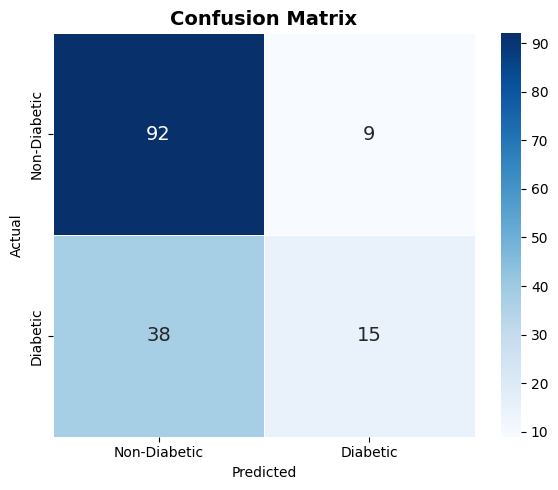

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            linewidths=0.5, annot_kws={'size': 14})

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Lets draw ROC curve

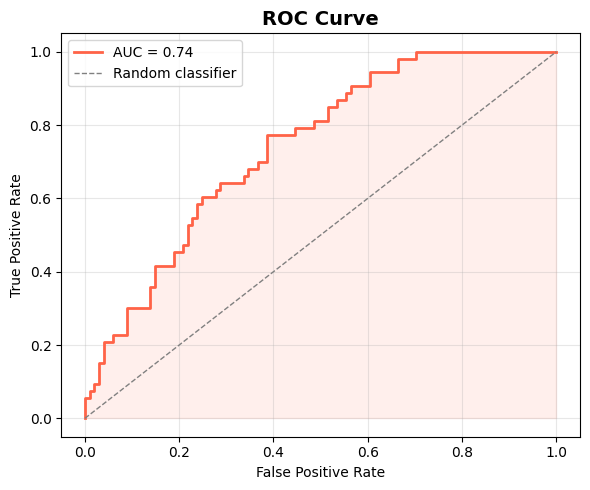

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='tomato', linewidth=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='tomato')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Lets draw 2d calssificaion plot

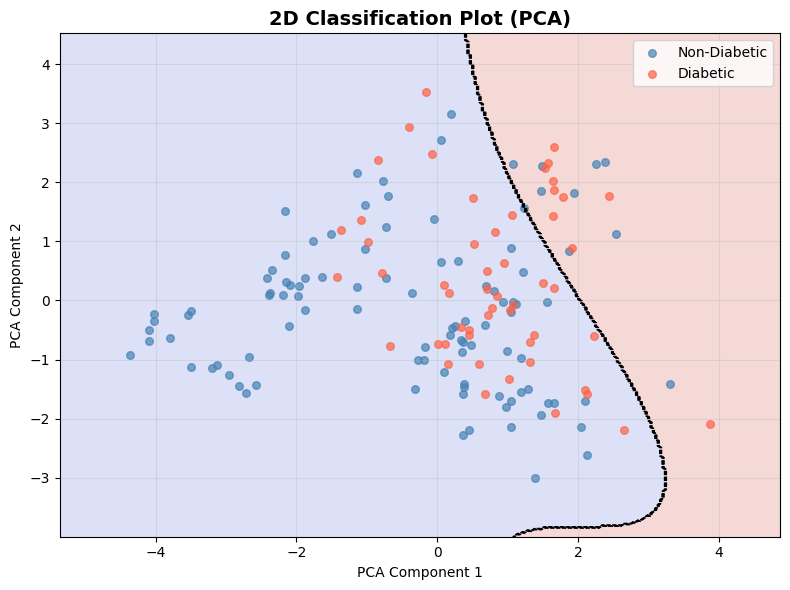

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_2d  = pca.fit_transform(X_test)
X_train_2d = pca.transform(X_train)

from sklearn.svm import SVC
svm_2d = SVC(kernel='poly', C=1, degree=3, gamma='scale', probability=True)
svm_2d.fit(X_train_2d, y_train)

x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.contour(xx, yy, Z, colors='black', linewidths=0.8, linestyles='--')

plt.scatter(X_test_2d[y_test==0, 0], X_test_2d[y_test==0, 1],
            color='steelblue', s=30, alpha=0.7, label='Non-Diabetic')
plt.scatter(X_test_2d[y_test==1, 0], X_test_2d[y_test==1, 1],
            color='tomato', s=30, alpha=0.7, label='Diabetic')

plt.title('2D Classification Plot (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Lets view some sample predictions

In [23]:
import pandas as pd
import numpy as np

y_pred_all = best_model.predict(X_test)
y_prob_all = best_model.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'Actual':        ['Diabetic' if y == 1 else 'Non-Diabetic' for y in y_test],
    'Predicted':     ['Diabetic' if y == 1 else 'Non-Diabetic' for y in y_pred_all],
    'Prob (Diabetic)':   (y_prob_all * 100).round(2).astype(str) + '%',
    'Prob (Non-Diabetic)': ((1 - y_prob_all) * 100).round(2).astype(str) + '%',
    'Correct':       ['YES' if a == p else 'NO' for a, p in zip(y_test, y_pred_all)]
})

print("=" * 75)
print("                    SAMPLE PREDICTIONS (20 rows)")
print("=" * 75)
print(results_df.head(20).to_string(index=True))
print("=" * 75)
print(f"\nTotal Correct   : {(results_df['Correct'] == 'YES').sum()} / {len(results_df)}")
print(f"Total Incorrect : {(results_df['Correct'] == 'NO').sum()} / {len(results_df)}")

                    SAMPLE PREDICTIONS (20 rows)
          Actual     Predicted Prob (Diabetic) Prob (Non-Diabetic) Correct
0   Non-Diabetic  Non-Diabetic          48.11%              51.89%     YES
1       Diabetic  Non-Diabetic          33.45%              66.55%      NO
2       Diabetic  Non-Diabetic          31.46%              68.54%      NO
3   Non-Diabetic  Non-Diabetic          22.13%              77.87%     YES
4       Diabetic  Non-Diabetic           29.7%               70.3%      NO
5   Non-Diabetic  Non-Diabetic          11.98%              88.02%     YES
6       Diabetic      Diabetic          74.72%              25.28%     YES
7       Diabetic  Non-Diabetic           23.0%               77.0%      NO
8   Non-Diabetic  Non-Diabetic          29.23%              70.77%     YES
9   Non-Diabetic  Non-Diabetic           24.5%               75.5%     YES
10      Diabetic  Non-Diabetic          27.01%              72.99%      NO
11  Non-Diabetic  Non-Diabetic          20.74%     